

# Emilio Arias

## Mineríade Datos 

### Exploratoy Data Analysis (EDA)





```
 # Análisis exploratorio de datos (EDA)

Este notebook presenta un análisis exploratorio de datos (EDA) detallado de un conjunto de datos que incluye información sobre artistas y sus canciones que han aparecido en la lista de éxitos. El objetivo de este análisis es obtener una comprensión profunda de las características, tendencias y patrones que pueden estar presentes en los datos relacionados con la música popular.

El conjunto de datos contiene información variada como el título de la canción, el artista, el estado de ánimo de la canción, el tempo, el género, el tipo de artista (por ejemplo, solista, grupo), la fecha en la que la canción apareció en la lista de éxitos, la duración de la canción en segundos, si alcanzó el top de la lista de éxitos, y el año de nacimiento del artista.

### Estructura del Notebook
Carga y Exploración Inicial de Datos: Cargaremos el conjunto de datos y realizaremos una exploración inicial para entender su estructura y composición.

* Análisis Estadístico Descriptivo: Proporcionaremos estadísticas descriptivas para entender mejor las distribuciones y características clave de las variables numéricas.

* Análisis de Valores Faltantes: Revisaremos el conjunto de datos en busca de valores faltantes y discutiremos posibles enfoques para su tratamiento.

* Visualización de Datos: Utilizaremos diversas visualizaciones, como boxplots, para explorar distribuciones y relaciones en los datos.

* Análisis de Subconjuntos de Datos: Realizaremos análisis específicos en subconjuntos del conjunto de datos, como el análisis de artistas nacidos después de 1950, para explorar tendencias específicas y patrones en grupos más definidos.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score

1. id: Identificador único para cada registro.
2. title: Título de la canción.
3. artist: Artista o grupo musical.
4. mood: Estado de ánimo asociado con la canción.
5. tempo: Tempo de la canción.
6. genre: Género musical.
7. artist_type: Tipo de artista (por ejemplo, masculino, femenino, grupo).
8. chart_date: Fecha en la que la canción entró en las listas de Billboard.
9. durationSeg: Duración de la canción en segundos.
10. top: Indica si la canción alcanzó el top de las listas (1 para sí, 0 para no).
11. anioNacimiento: Año de nacimiento del artista.



In [2]:
path="/content/artists_billboard.csv"
data = pd.read_csv(path)
data.head()

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191,0,1975
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368,0,1989
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223,1,1993
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206,0,1989
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232,0,0


#EDA#

In [3]:
data.shape


(635, 11)

Tiene 635 filas y 11 columnas

In [4]:
data.columns

Index(['id', 'title', 'artist', 'mood', 'tempo', 'genre', 'artist_type',
       'chart_date', 'durationSeg', 'top', 'anioNacimiento'],
      dtype='object')

In [5]:
# Display all the column names (headers) in the dataset
data.columns.tolist()


['id',
 'title',
 'artist',
 'mood',
 'tempo',
 'genre',
 'artist_type',
 'chart_date',
 'durationSeg',
 'top',
 'anioNacimiento']

In [6]:
data.describe()

,id,chart_date,durationSeg,top,anioNacimiento
count,635.000000,6.350000e+02,635.000000,635.000000,635.000000
mean,317.000000,2.013036e+07,321.768504,0.222047,1548.590551
std,183.452991,2.617996e+04,633.753787,0.415950,820.470454
min,0.000000,2.004021e+07,0.000000,0.000000,0.000000
25%,158.500000,2.014010e+07,200.000000,0.000000,1969.000000
50%,317.000000,2.014051e+07,232.000000,0.000000,1981.000000
75%,475.500000,2.014101e+07,266.500000,0.000000,1986.000000
max,634.000000,2.015031e+07,6840.000000,1.000000,1999.000000


In [7]:
# Check for missing values in the dataset
missing_values = data.isnull().sum()
missing_values[missing_values > 0]
#esto es una nota

,0


In [10]:
# Imputar solo columnas numéricas con su media
data = data.fillna(data.mean(numeric_only=True))
display(data)

,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191,0,1975
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368,0,1989
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223,1,1993
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206,0,1989
4,4,Automatic,MIRANDA LAMBERT,Yearning,Medium Tempo,Traditional,Female,20140301,232,0,0
...,...,...,...,...,...,...,...,...,...,...,...
630,630,The Blower's Daughter,MATT McANDREW,Romantic,Medium Tempo,Pop,Male,20141220,881,0,1990
631,631,First Love,JENNIFER LOPEZ,Peaceful,Slow Tempo,Pop,Female,20140705,238,0,1970
632,632,No One,ALICIA KEYS,Sophisticated,Slow Tempo,Urban,Female,20071201,157,1,1981
633,633,She Came To Give It To You,USHER featuring NICKI MINAJ,Energizing,Medium Tempo,Urban,Mixed,20140913,209,0,1982


In [8]:
# Revisando estadísticas descriptivas básicas y la presencia de valores faltantes
summary = data.describe(include='all')
missing_values = data.isnull().sum()

summary, missing_values


(                id title artist        mood         tempo  genre artist_type  \
 count   635.000000   635    635         635           635    635         635   
 unique         NaN   626    423          23             3      9           3   
 top            NaN  Roar  DRAKE  Empowering  Medium Tempo  Urban        Male   
 freq           NaN     2     10          88           517    215         387   
 mean    317.000000   NaN    NaN         NaN           NaN    NaN         NaN   
 std     183.452991   NaN    NaN         NaN           NaN    NaN         NaN   
 min       0.000000   NaN    NaN         NaN           NaN    NaN         NaN   
 25%     158.500000   NaN    NaN         NaN           NaN    NaN         NaN   
 50%     317.000000   NaN    NaN         NaN           NaN    NaN         NaN   
 75%     475.500000   NaN    NaN         NaN           NaN    NaN         NaN   
 max     634.000000   NaN    NaN         NaN           NaN    NaN         NaN   
 
           chart_date  dur

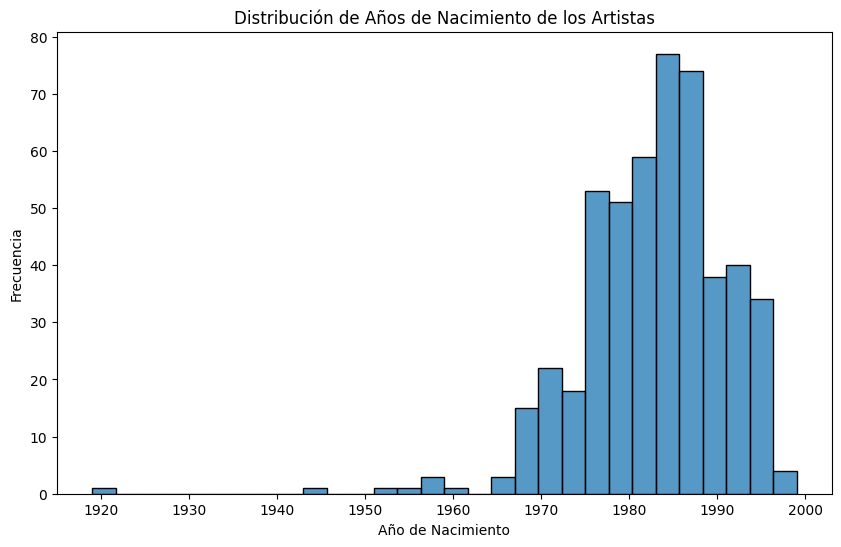

np.int64(139)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando los registros con años de nacimiento que parecen ser válidos (mayores a 1900)
valid_birth_years = data[data['anioNacimiento'] > 1900]

# Histograma de los años de nacimiento
plt.figure(figsize=(10, 6))
sns.histplot(valid_birth_years['anioNacimiento'], kde=False, bins=30)
plt.title('Distribución de Años de Nacimiento de los Artistas')
plt.xlabel('Año de Nacimiento')
plt.ylabel('Frecuencia')
plt.show()

# Contando los valores que son 0 o menores a 1900
invalid_birth_years_count = data[data['anioNacimiento'] <= 1900]['anioNacimiento'].count()
invalid_birth_years_count


In [13]:
# Filtrando el conjunto de datos para incluir solo artistas nacidos a partir de 1950
filtered_data = data[data['anioNacimiento'] >= 1950]

# Verificando las dimensiones del conjunto de datos filtrado y mostrando las primeras filas
filtered_data_shape = filtered_data.shape
filtered_data.head()




,id,title,artist,mood,tempo,genre,artist_type,chart_date,durationSeg,top,anioNacimiento
0,0,Small Town Throwdown,BRANTLEY GILBERT featuring JUSTIN MOORE & THOM...,Brooding,Medium Tempo,Traditional,Male,20140628,191,0,1975
1,1,Bang Bang,"JESSIE J, ARIANA GRANDE & NICKI MINAJ",Energizing,Medium Tempo,Pop,Female,20140816,368,0,1989
2,2,Timber,PITBULL featuring KE$HA,Excited,Medium Tempo,Urban,Mixed,20140118,223,1,1993
3,3,Sweater Weather,THE NEIGHBOURHOOD,Brooding,Medium Tempo,Alternative & Punk,Male,20140104,206,0,1989
5,5,Where Is At (Yep Yep),DUSTIN LYNCH,Upbeat,Medium Tempo,Traditional,Male,20140531,219,0,1990


Una justificación para eliminar los datos de artistas nacidos antes de 1950 del análisis puede basarse en varios puntos clave relacionados con la relevancia, precisión y contexto del estudio:

* Relevancia Contemporánea: La música y la popularidad de los artistas pueden estar fuertemente influenciadas por tendencias y gustos contemporáneos. Los artistas nacidos después de 1950 tienen más probabilidades de haber estado activos durante períodos más relevantes para las tendencias musicales actuales, lo que hace que su análisis sea más pertinente para entender la música popular moderna.

* Precisión de los Datos: Los datos de años de nacimiento muy antiguos pueden ser menos precisos o confiables. Esto se debe a que la recolección y el registro de datos en décadas pasadas no eran tan rigurosos como en tiempos más recientes. Al limitar el análisis a artistas nacidos después de 1950, se reduce el riesgo de trabajar con datos inexactos o mal registrados.

* Cambio en la Industria Musical: La industria de la música ha experimentado cambios significativos en las últimas décadas, tanto en términos de tecnología como de cultura. Los artistas nacidos después de 1950 están más alineados con la era de la música grabada, la radio, la televisión y, más recientemente, el streaming digital, lo que los hace más representativos de la industria musical tal como la conocemos hoy.

* Datos Atípicos y Anomalías: La presencia de años de nacimiento extremadamente antiguos o incorrectos (como los años 0 o pre-1900) sugiere errores en los datos o entradas atípicas. Eliminar estos datos mejora la calidad general del análisis al centrarse en registros más confiables.

* Enfoque en Generaciones Relevantes: Al centrarse en artistas nacidos después de 1950, el análisis puede enfocarse en generaciones que han sido culturalmente significativas en la música popular reciente, incluyendo los baby boomers, la Generación X y los millennials, que han tenido un impacto considerable en la evolución de la música popular.

En resumen, limitar el análisis a artistas nacidos después de 1950 mejora la relevancia, precisión y coherencia del estudio, asegurando que los hallazgos sean más aplicables al contexto actual de la industria musical.

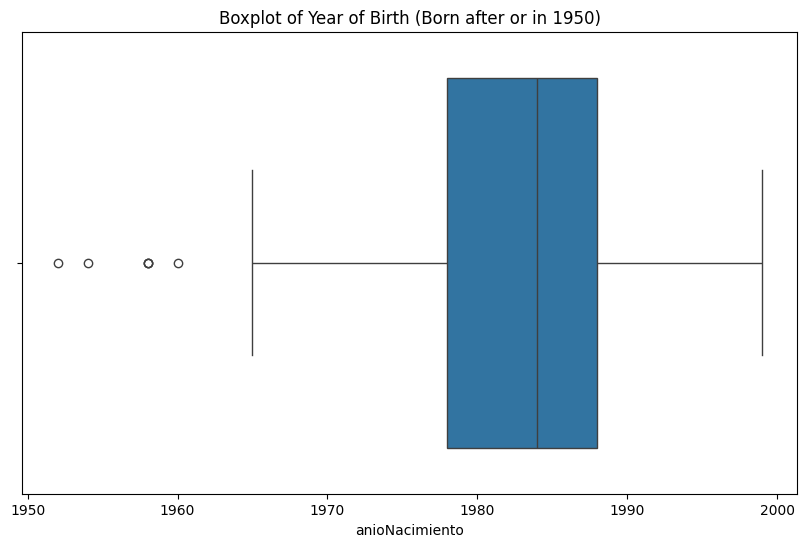

In [11]:
# Boxplot for the "anioNacimiento" column in the filtered data (artists born after or in 1950)
plt.figure(figsize=(10, 6))
sns.boxplot(x=filtered_data['anioNacimiento'])
plt.title('Boxplot of Year of Birth (Born after or in 1950)')
plt.show()


## Como leer un boxplot

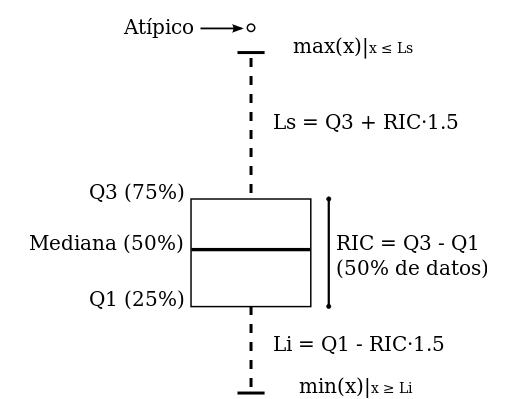![image.png](
  
)

<ipython-input-14-7cda686f863b>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['generation'] = filtered_data['anioNacimiento'].apply(classify_generation)


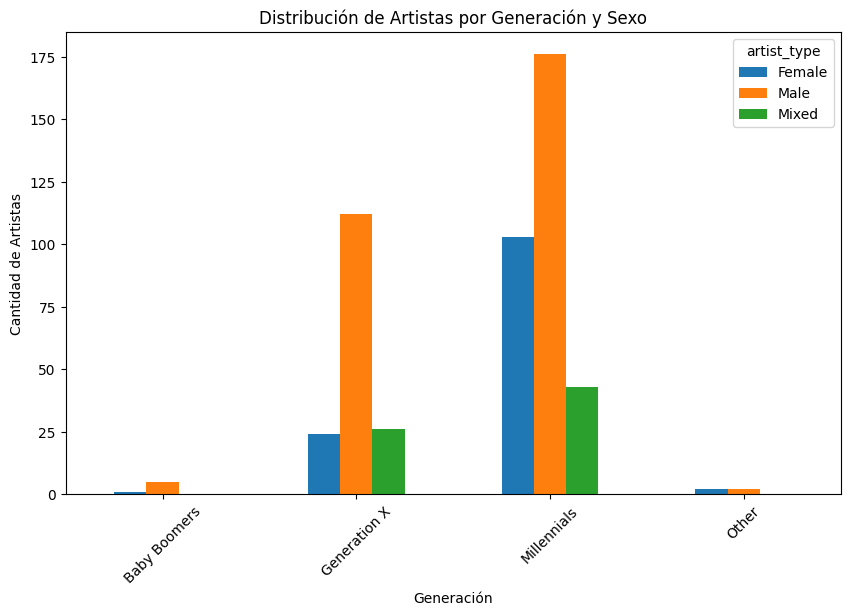

In [14]:
# Creando una columna para clasificar a los artistas en generaciones
def classify_generation(year):
    if 1950 <= year <= 1964:
        return 'Baby Boomers'
    elif 1965 <= year <= 1980:
        return 'Generation X'
    elif 1981 <= year <= 1996:
        return 'Millennials'
    else:
        return 'Other'

filtered_data['generation'] = filtered_data['anioNacimiento'].apply(classify_generation)

# Conteo de artistas por generación y sexo
generation_sex_count = filtered_data.groupby(['generation', 'artist_type']).size().unstack()

# Gráfico de barras
generation_sex_count.plot(kind='bar', figsize=(10, 6))
plt.title('Distribución de Artistas por Generación y Sexo')
plt.xlabel('Generación')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.show()


Baby Boomers: Normalmente se considera que esta generación abarca a las personas nacidas entre 1946 y 1964. Dado que ya hemos filtrado el conjunto de datos para incluir solo a aquellos nacidos después de 1950, utilizaremos el rango de 1950 a 1964 para los baby boomers en nuestro análisis.

Generación X: Esta generación abarca a los nacidos entre 1965 y 1980.

Millennials (Generación Y): Los millennials son generalmente considerados como aquellos nacidos entre 1981 y 1996.

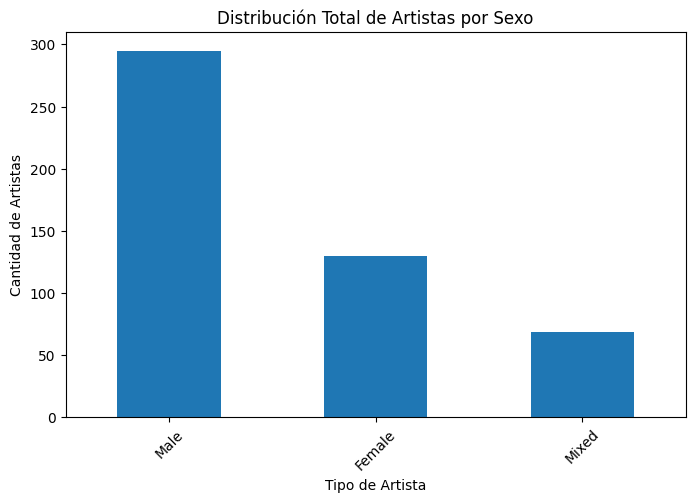

In [15]:
# Conteo de artistas por sexo
sex_count = filtered_data['artist_type'].value_counts()

# Gráfico de barras para la distribución de artistas por sexo
sex_count.plot(kind='bar', figsize=(8, 5))
plt.title('Distribución Total de Artistas por Sexo')
plt.xlabel('Tipo de Artista')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.show()


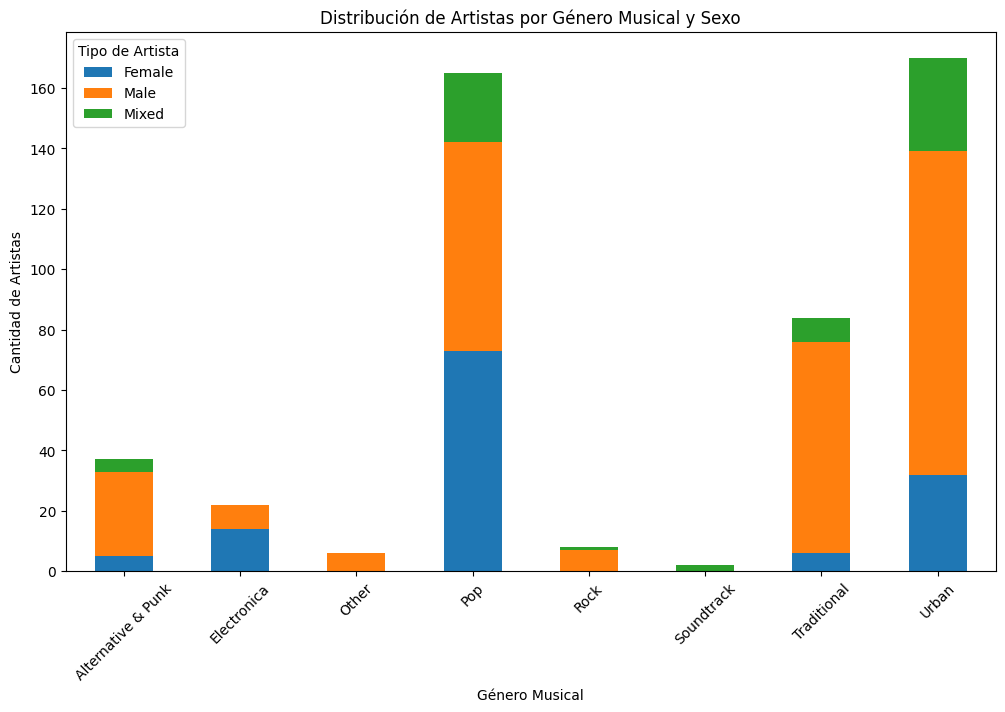

In [16]:
# Gráfico de barras apilado para la distribución de artistas por sexo y género musical
genre_sex_count = filtered_data.groupby(['genre', 'artist_type']).size().unstack().fillna(0)

genre_sex_count.plot(kind='bar', stacked=True, figsize=(12, 7), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('Distribución de Artistas por Género Musical y Sexo')
plt.xlabel('Género Musical')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Artista')
plt.show()


filtered_data.groupby(['genre', 'artist_type']):

filtered_data es el DataFrame que contiene los datos filtrados (en este caso, probablemente los artistas nacidos en o después de 1950).
* .groupby(['genre', 'artist_type']) agrupa los datos por dos columnas: 'genre' y 'artist_type'. Esto significa que se formarán grupos únicos para cada combinación de género musical y tipo de artista (por ejemplo, solista masculino, grupo femenino, etc.).
.size():

Después de agrupar los datos,
* .size() cuenta el número de ocurrencias en cada grupo. Esto proporciona un conteo de cuántas veces aparece cada combinación única de género y tipo de artista en el conjunto de datos.
* .unstack():  se utiliza para pivotar uno de los niveles de índices de grupo (en este caso, probablemente 'artist_type') y convertirlo en columnas. Esto hace que los datos sean más legibles y permite una mejor visualización. El resultado es una tabla donde las filas representan los géneros y las columnas representan los tipos de artistas, con los valores siendo el conteo de ocurrencias.
* .fillna(0):Finalmente, .fillna(0) reemplaza cualquier valor nulo (NaN) en el DataFrame resultante con 0. Esto es útil en caso de que no haya ocurrencias para alguna combinación de género y tipo de artista, asegurando que todos los valores sean numéricos.

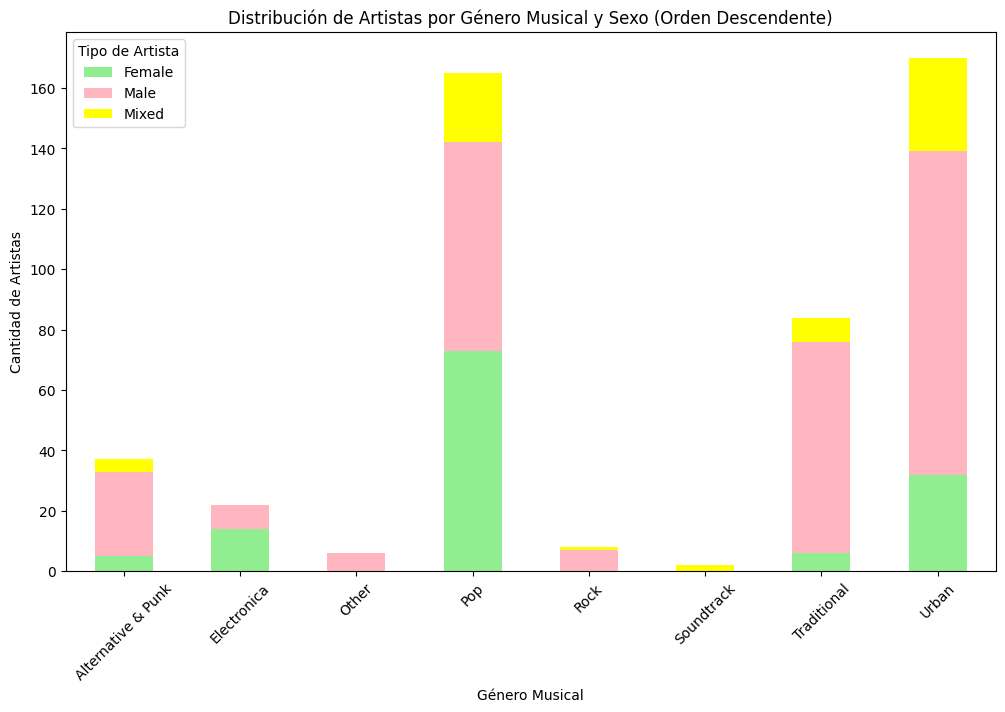

In [ ]:
# Definiendo colores específicos para cada tipo de artista
custom_colors = ['lightgreen', 'lightpink', 'yellow']

# Gráfico de barras apilado con colores específicos
genre_sex_count.plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
plt.title('Distribución de Artistas por Género Musical y Sexo (Orden Descendente)')
plt.xlabel('Género Musical')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Artista')
plt.show()



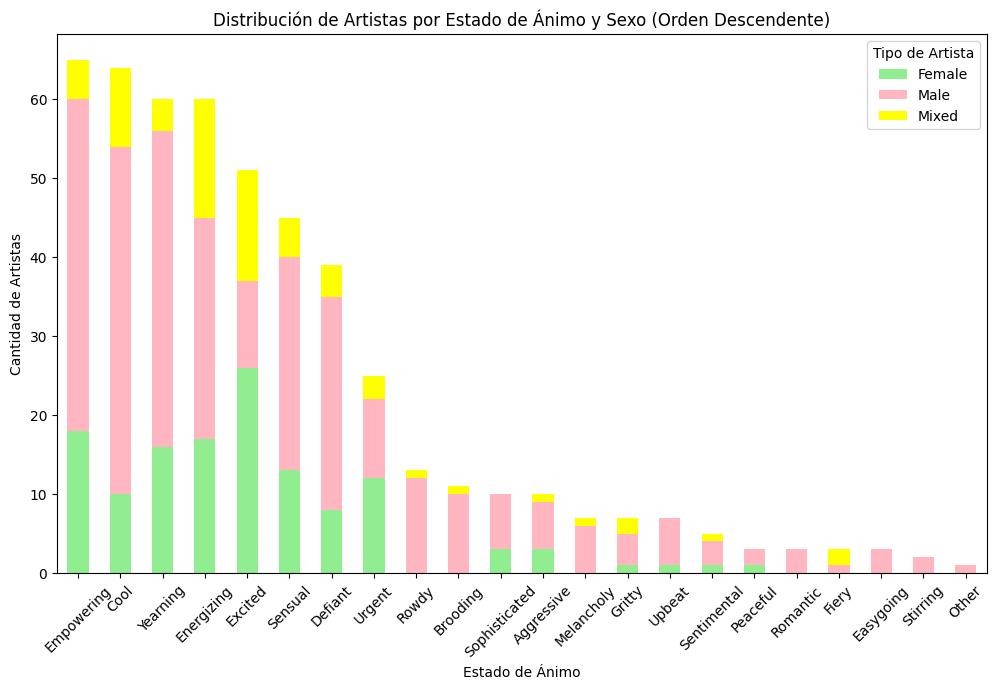

In [ ]:
# Gráfico de barras apilado para la distribución de artistas por estado de ánimo (mood) y sexo
mood_sex_count = filtered_data.groupby(['mood', 'artist_type']).size().unstack().fillna(0)

# Ordenando los estados de ánimo de forma descendente según el total de artistas
mood_sex_count_sorted = mood_sex_count.sum(axis=1).sort_values(ascending=False).index
mood_sex_count_sorted = mood_sex_count.loc[mood_sex_count_sorted]

# Gráfico de barras apilado con colores específicos para cada tipo de artista
mood_sex_count_sorted.plot(kind='bar', stacked=True, figsize=(12, 7), color=custom_colors)
plt.title('Distribución de Artistas por Estado de Ánimo y Sexo (Orden Descendente)')
plt.xlabel('Estado de Ánimo')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Artista')
plt.show()


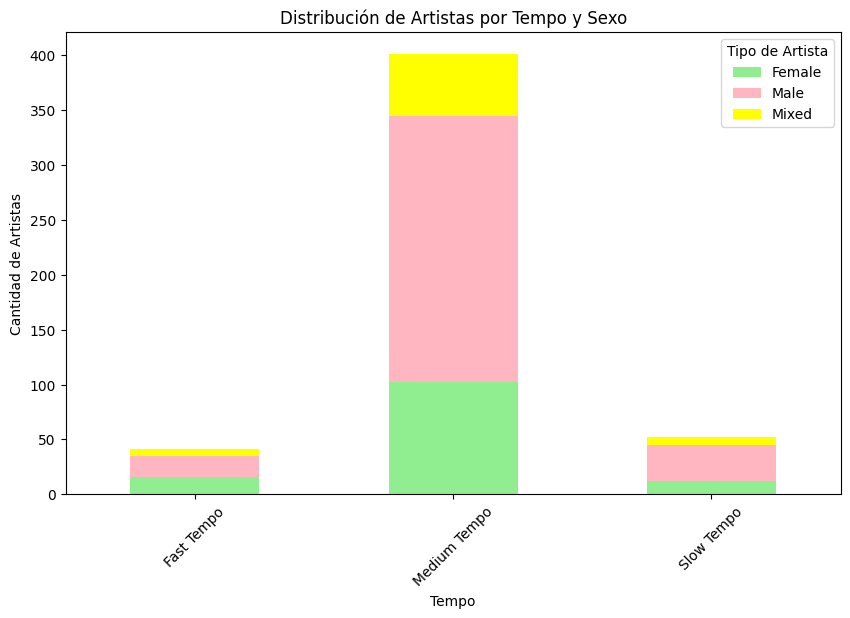

In [ ]:
# Gráfico de barras apilado para la distribución de artistas por tempo y sexo
tempo_sex_count = filtered_data.groupby(['tempo', 'artist_type']).size().unstack().fillna(0)

# Gráfico de barras apilado con colores específicos para cada tipo de artista
tempo_sex_count.plot(kind='bar', stacked=True, figsize=(10, 6), color=custom_colors)
plt.title('Distribución de Artistas por Tempo y Sexo')
plt.xlabel('Tempo')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Artista')
plt.show()


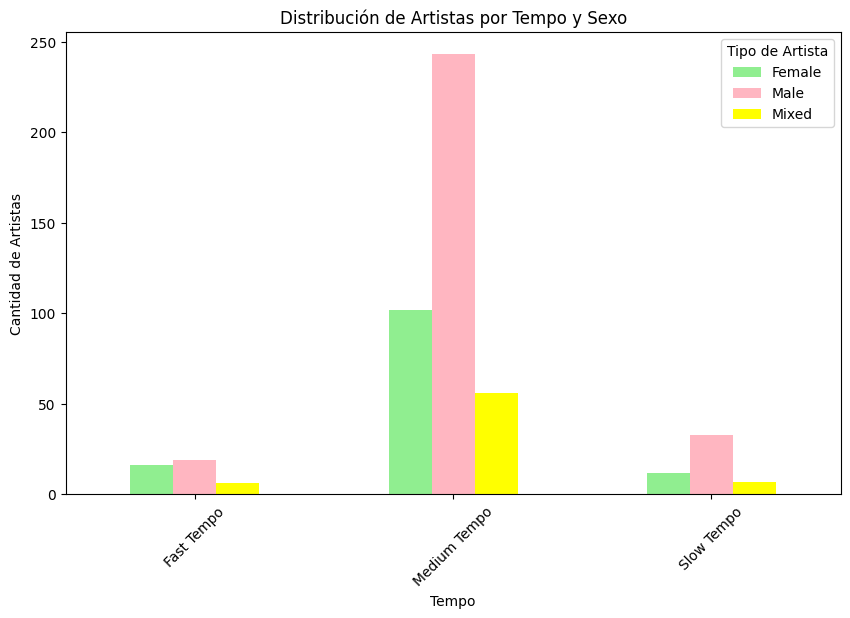

In [ ]:
# Gráfico de barras no apilado para la distribución de artistas por tempo y sexo
tempo_sex_count.plot(kind='bar', stacked=False, figsize=(10, 6), color=custom_colors)
plt.title('Distribución de Artistas por Tempo y Sexo')
plt.xlabel('Tempo')
plt.ylabel('Cantidad de Artistas')
plt.xticks(rotation=45)
plt.legend(title='Tipo de Artista')
plt.show()


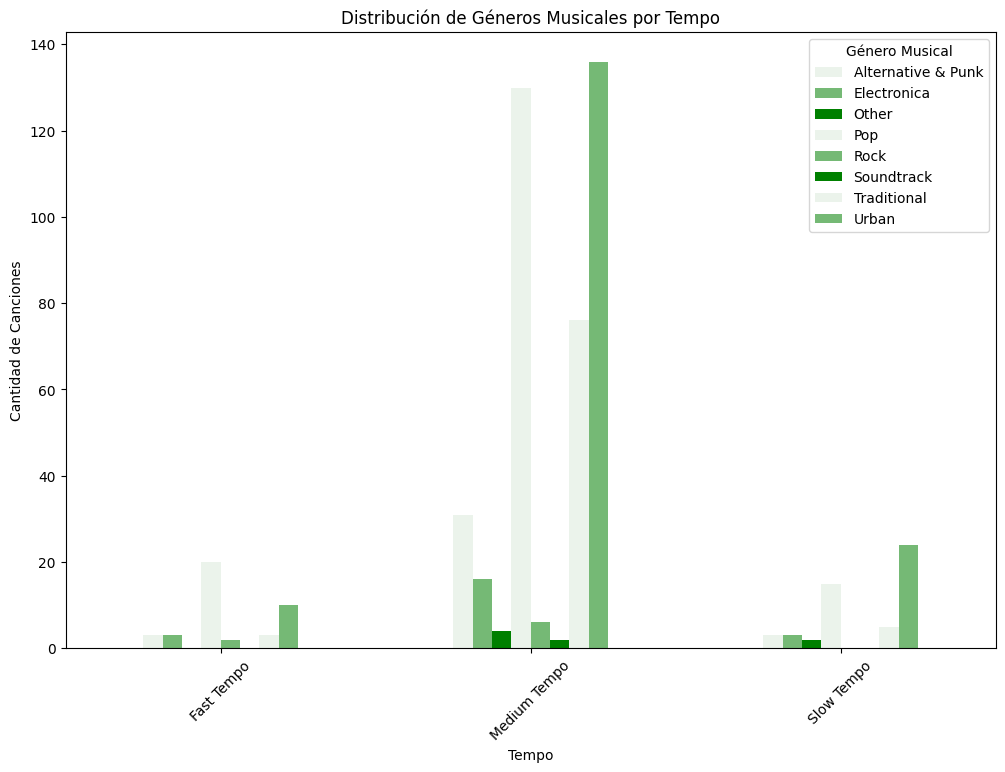

In [ ]:
# Creando una paleta de colores en escala de verdes
green_palette = sns.light_palette("green", n_colors=3)

# Gráfico de barras para la distribución de géneros musicales por tempo
tempo_genre_count = filtered_data.groupby(['tempo', 'genre']).size().unstack().fillna(0)

# Gráfico de barras no apilado con paleta de verdes
tempo_genre_count.plot(kind='bar', stacked=False, figsize=(12, 8), color=green_palette)
plt.title('Distribución de Géneros Musicales por Tempo')
plt.xlabel('Tempo')
plt.ylabel('Cantidad de Canciones')
plt.xticks(rotation=45)
plt.legend(title='Género Musical')
plt.show()


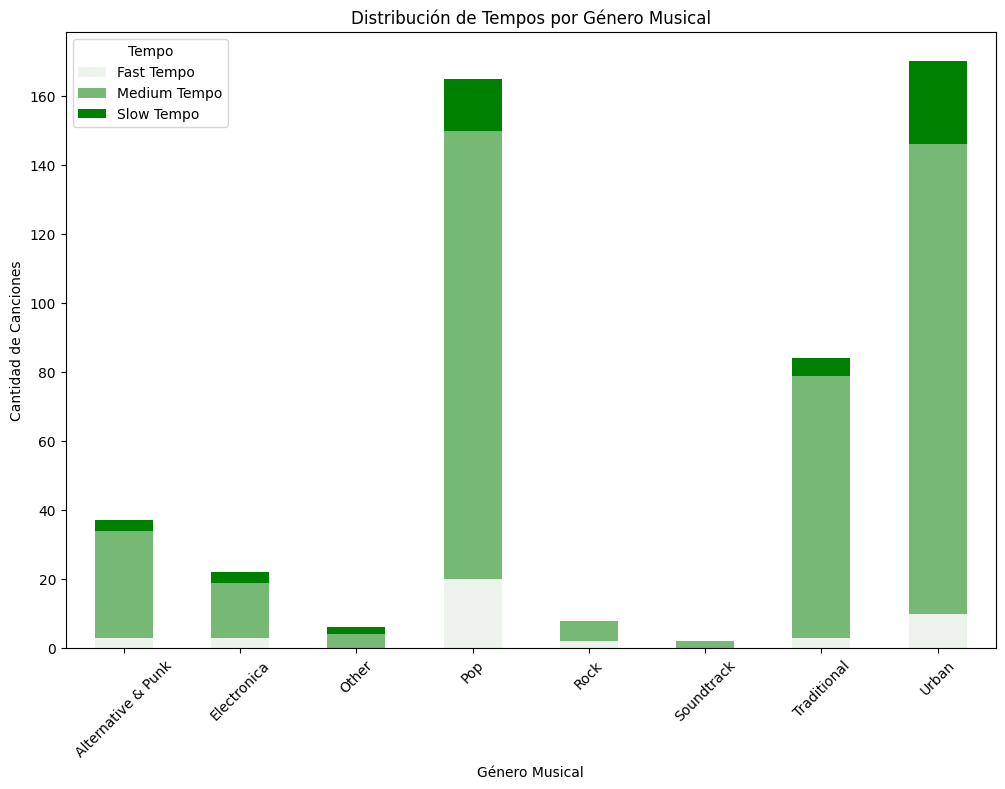

In [ ]:
# Gráfico de barras apilado para la distribución de tempos por género musical
genre_tempo_count = filtered_data.groupby(['genre', 'tempo']).size().unstack().fillna(0)

# Gráfico de barras apilado con paleta de verdes
genre_tempo_count.plot(kind='bar', stacked=True, figsize=(12, 8), color=green_palette)
plt.title('Distribución de Tempos por Género Musical')
plt.xlabel('Género Musical')
plt.ylabel('Cantidad de Canciones')
plt.xticks(rotation=45)
plt.legend(title='Tempo')
plt.show()
